# LLM Comparison — Llama 3.1 8B vs GPT-4o-mini

Compares the effect of swapping the prediction LLM while keeping retrieval identical.

| Config | Embedder | LLM | File |
|---|---|---|---|
| BGE+RR Llama | BGE-large | Llama 3.1 8B | exp4_rag_bge_reranker.csv |
| BGE+RR GPT | BGE-large | GPT-4o-mini | exp6_bge_reranker_gpt4omini.csv |
| TE+RR Llama | TE-3-large | Llama 3.1 8B | exp5_rag_te_reranker.csv |
| TE+RR GPT | TE-3-large | GPT-4o-mini | exp7_te_reranker_gpt4omini.csv |

**Core question:** Is the remaining performance gap after retrieval caused by LLM capability or by retrieval precision?

## 1. Setup

In [8]:
import sys
sys.path.insert(0, '/home/ma/ma_ma/ma_mpandya/RAG_Data_Cleaning/PyDI/venv/lib64/python3.12/site-packages')
sys.path.insert(0, '/home/ma/ma_ma/ma_mpandya/RAG_Data_Cleaning/PyDI/venv/lib/python3.12/site-packages')

import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import seaborn as sns
from sentence_transformers import CrossEncoder
import warnings
warnings.filterwarnings('ignore')

RESULTS_DIR  = 'results'
FIGURES_DIR  = 'figures'
HF_CACHE     = '/home/ma/ma_ma/ma_mpandya/.cache/huggingface/hub'
os.makedirs(FIGURES_DIR, exist_ok=True)

NUMERIC_ATTRIBUTES = {'read_speed_mb_s','write_speed_mb_s','height_mm','width_mm'}
TEXT_ATTRIBUTES    = {'bus_type','model_number','model'}

# Colors
NAVY='#1E3A5F'; TEAL='#0891B2'; GREEN='#059669'; ORANGE='#D97706'
GREY='#64748B'; RED='#DC2626'; GREYL='#E2E8F0'; GREYC='#F8FAFC'

# Load CrossEncoder
CE_SNAP = glob.glob(f'{HF_CACHE}/models--cross-encoder--ms-marco-MiniLM-L-6-v2/snapshots/*/')
CE_PATH = CE_SNAP[0].rstrip('/') if CE_SNAP else 'cross-encoder/ms-marco-MiniLM-L-6-v2'
cross_encoder = CrossEncoder(CE_PATH)
print(f'CrossEncoder: {CE_PATH}')

# Files to compare
FILES = {
    'BGE+RR\nLlama 3.1 8B':  f'results_mit_UNKNOWN/exp4_rag_bge_reranker.csv',
    'BGE+RR\nGPT-4o-mini':   f'{RESULTS_DIR}/exp6_bge_reranker_gpt4omini.csv',
    'TE+RR\nLlama 3.1 8B':   f'results_mit_UNKNOWN/exp5_rag_te_reranker.csv',
    'TE+RR\nGPT-4o-mini':    f'{RESULTS_DIR}/exp7_te_reranker_gpt4omini.csv',
}

# Short labels for tables
SHORT = {
    'BGE+RR\nLlama 3.1 8B': 'BGE+Llama',
    'BGE+RR\nGPT-4o-mini':  'BGE+GPT',
    'TE+RR\nLlama 3.1 8B':  'TE+Llama',
    'TE+RR\nGPT-4o-mini':   'TE+GPT',
}
print('Setup complete.')

CrossEncoder: /home/ma/ma_ma/ma_mpandya/.cache/huggingface/hub/models--cross-encoder--ms-marco-MiniLM-L-6-v2/snapshots/c5ee24cb16019beea0893ab7796b1df96625c6b8
Setup complete.


## 2. Evaluation Functions

In [9]:
def fix_pred(pred):
    if isinstance(pred, str) and pred.strip().upper().startswith('VALUE:'):
        val = pred.strip().split(':',1)[1].strip()
        return 'UNKNOWN' if val.upper() in {'UNKNOWN','NONE','NULL','NAN',''} else val
    return pred

def is_unk(v): return str(v).strip().lower() in {'unknown','nan','none','null',''}

def is_correct(pred, gt, attr):
    if is_unk(pred): return False
    if attr in NUMERIC_ATTRIBUTES:
        try:
            p = float(str(pred).replace(',','').strip())
            g = float(str(gt).replace(',','').strip())
            return p == g
        except: return False
    p, g = str(pred).lower().strip(), str(gt).lower().strip()
    return p == g or p in g or g in p

def eval_ce(pred, gt, attr):
    if is_unk(pred): return 'wrong'
    if attr in NUMERIC_ATTRIBUTES:
        try:
            p = float(str(pred).replace(',','').strip())
            g = float(str(gt).replace(',','').strip())
            if g == 0: return 'correct' if p == 0 else 'wrong'
            r = abs(p-g)/abs(g)
            return 'correct' if r==0.0 else ('acceptable' if r<=0.10 else 'wrong')
        except: return 'wrong'
    score = cross_encoder.predict([[gt, pred]])[0]
    return 'correct' if score > 2.0 else ('acceptable' if score > -1.0 else 'wrong')

print('Evaluation functions ready.')

Evaluation functions ready.


## 3. Load and Evaluate All Configs

In [11]:
dfs     = {}
summary = []

for label, fpath in FILES.items():
    if not os.path.exists(fpath):
        print(f'  ⚠️  Not found: {fpath} — skipping'); continue
    df = pd.read_csv(fpath)
    df['predicted'] = df['predicted'].apply(fix_pred)
    df['std']  = df.apply(lambda r: is_correct(r['predicted'], r['ground_truth'], r['attribute']), axis=1)
    df['ce']   = df.apply(lambda r: eval_ce(r['predicted'], r['ground_truth'], r['attribute']), axis=1)
    df['unk']  = df['predicted'].apply(is_unk)
    dfs[label] = df
    summary.append({
        'label':   label,
        'short':   SHORT[label],
        'std':     df['std'].mean()*100,
        'ce':      df['ce'].isin(['correct','acceptable']).mean()*100,
        'unknown': df['unk'].mean()*100,
        'n':       len(df)
    })
    print(f'  ✓ {SHORT[label]:<12} Std: {df["std"].mean()*100:.1f}%  CE: {df["ce"].isin(["correct","acceptable"]).mean()*100:.1f}%  UNK: {df["unk"].mean()*100:.1f}%')

sum_df = pd.DataFrame(summary)
print(f'\nLoaded {len(dfs)} configs.')

  ✓ BGE+Llama    Std: 72.9%  CE: 78.1%  UNK: 3.1%
  ✓ BGE+GPT      Std: 64.6%  CE: 67.7%  UNK: 27.1%
  ✓ TE+Llama     Std: 71.9%  CE: 83.3%  UNK: 2.1%
  ✓ TE+GPT       Std: 65.6%  CE: 70.8%  UNK: 22.9%

Loaded 4 configs.


## Figure 1 — Overall Accuracy: Llama vs GPT-4o-mini

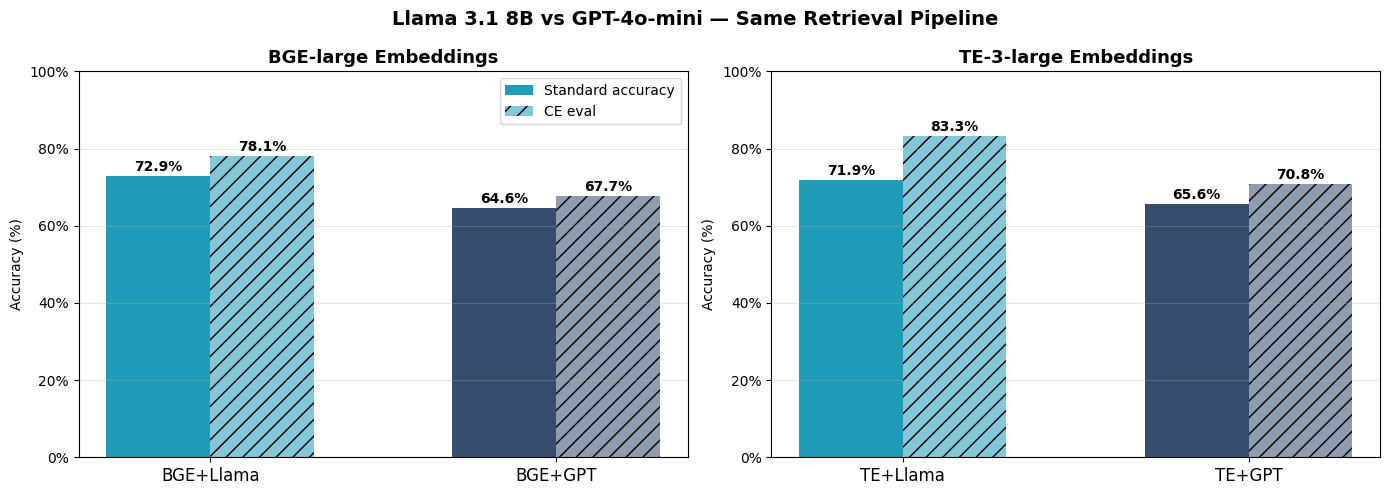

✓ llm_comparison_overall.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Group by embedder
for ax_i, (embedder, configs) in enumerate([
    ('BGE-large', ['BGE+RR\nLlama 3.1 8B', 'BGE+RR\nGPT-4o-mini']),
    ('TE-3-large', ['TE+RR\nLlama 3.1 8B', 'TE+RR\nGPT-4o-mini']),
]):
    ax = axes[ax_i]
    sub = sum_df[sum_df['label'].isin(configs)]
    x = np.arange(len(sub)); w = 0.3

    b1 = ax.bar(x-w/2, sub['std'], w, color=[TEAL, NAVY], alpha=0.9, label='Standard accuracy')
    b2 = ax.bar(x+w/2, sub['ce'],  w, color=[TEAL, NAVY], alpha=0.5, label='CE eval', hatch='//')

    for bar in list(b1)+list(b2):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f'{bar.get_height():.1f}%', ha='center', va='bottom',
                fontsize=10, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels([SHORT[c] for c in configs], fontsize=12)
    ax.set_ylabel('Accuracy (%)'); ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_title(f'{embedder} Embeddings', fontsize=13, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    if ax_i == 0:
        ax.legend(fontsize=10)

plt.suptitle('Llama 3.1 8B vs GPT-4o-mini — Same Retrieval Pipeline',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/llm_comparison_overall.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ llm_comparison_overall.png')

## Figure 2 — Per-Attribute Heatmap: All 4 Configs

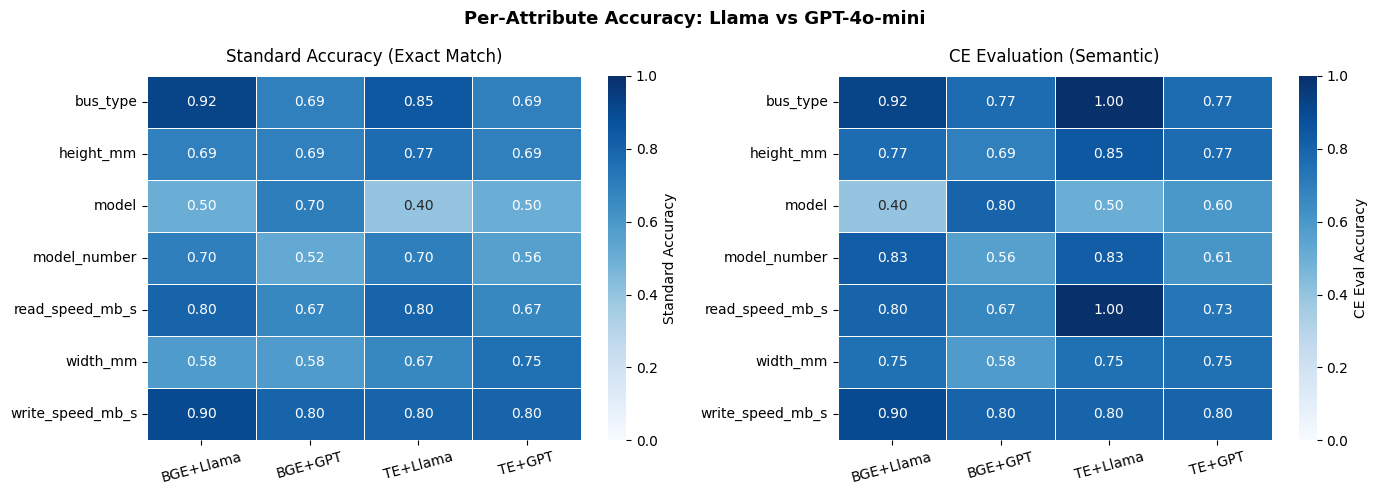

✓ llm_comparison_heatmap.png


In [13]:
attrs = sorted(list(dfs.values())[0]['attribute'].unique())
labels = [SHORT[l] for l in FILES if l in dfs]

# Standard accuracy heatmap
heatmap_std = pd.DataFrame(index=attrs, columns=labels)
for label in FILES:
    if label not in dfs: continue
    short = SHORT[label]
    df = dfs[label]
    for attr in attrs:
        sub = df[df['attribute']==attr]
        heatmap_std.loc[attr, short] = round(sub['std'].mean(), 3)
heatmap_std = heatmap_std.astype(float)

# CE eval heatmap
heatmap_ce = pd.DataFrame(index=attrs, columns=labels)
for label in FILES:
    if label not in dfs: continue
    short = SHORT[label]
    df = dfs[label]
    for attr in attrs:
        sub = df[df['attribute']==attr]
        heatmap_ce.loc[attr, short] = round(sub['ce'].isin(['correct','acceptable']).mean(), 3)
heatmap_ce = heatmap_ce.astype(float)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(heatmap_std, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
            linewidths=0.5, linecolor='white', ax=axes[0],
            cbar_kws={'label': 'Standard Accuracy'})
axes[0].set_title('Standard Accuracy (Exact Match)', fontsize=12, pad=10)
axes[0].tick_params(axis='x', rotation=15); axes[0].tick_params(axis='y', rotation=0)

sns.heatmap(heatmap_ce, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
            linewidths=0.5, linecolor='white', ax=axes[1],
            cbar_kws={'label': 'CE Eval Accuracy'})
axes[1].set_title('CE Evaluation (Semantic)', fontsize=12, pad=10)
axes[1].tick_params(axis='x', rotation=15); axes[1].tick_params(axis='y', rotation=0)

plt.suptitle('Per-Attribute Accuracy: Llama vs GPT-4o-mini', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/llm_comparison_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ llm_comparison_heatmap.png')

## Figure 3 — Delta: GPT-4o-mini minus Llama per Attribute

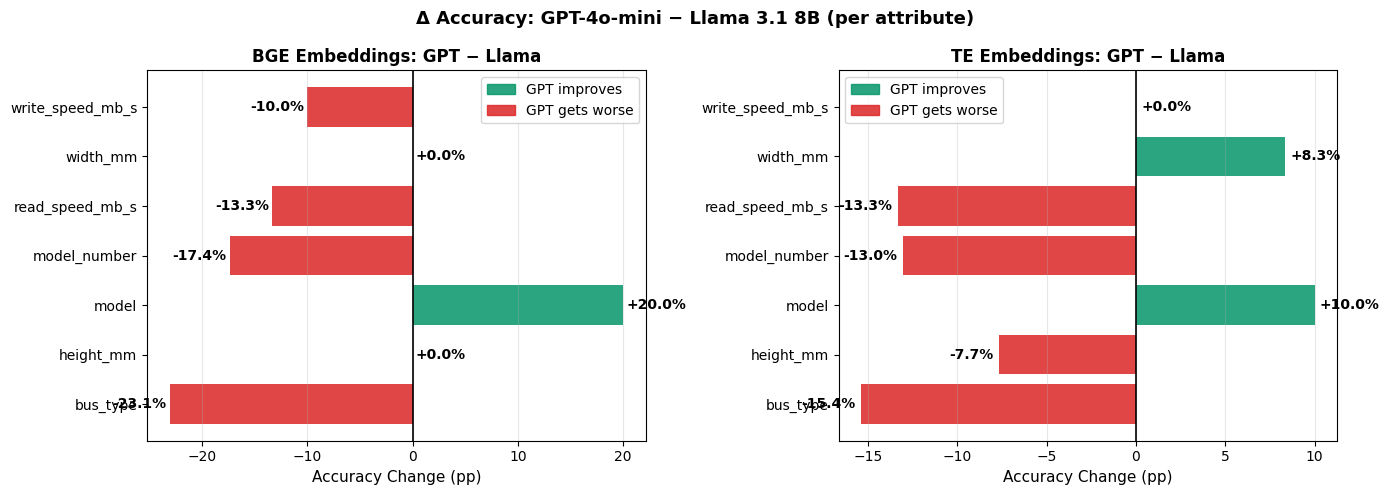

✓ llm_comparison_delta.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax_i, (title, llama_key, gpt_key) in enumerate([
    ('BGE Embeddings: GPT − Llama', 'BGE+RR\nLlama 3.1 8B', 'BGE+RR\nGPT-4o-mini'),
    ('TE Embeddings: GPT − Llama',  'TE+RR\nLlama 3.1 8B',  'TE+RR\nGPT-4o-mini'),
]):
    ax = axes[ax_i]
    if llama_key not in dfs or gpt_key not in dfs:
        ax.text(0.5, 0.5, 'Data not available', ha='center', va='center',
                transform=ax.transAxes, fontsize=13, color=GREY)
        continue

    deltas = []
    for attr in attrs:
        llama_acc = dfs[llama_key][dfs[llama_key]['attribute']==attr]['std'].mean()*100
        gpt_acc   = dfs[gpt_key][dfs[gpt_key]['attribute']==attr]['std'].mean()*100
        deltas.append(gpt_acc - llama_acc)

    y = np.arange(len(attrs))
    colors = [GREEN if d >= 0 else RED for d in deltas]
    bars = ax.barh(y, deltas, color=colors, alpha=0.85)

    for i, (bar, val) in enumerate(zip(bars, deltas)):
        ax.text(val+(0.3 if val>=0 else -0.3), i,
                f'{val:+.1f}%', va='center',
                ha='left' if val>=0 else 'right',
                fontsize=10, fontweight='bold')

    ax.set_yticks(y); ax.set_yticklabels(attrs, fontsize=10)
    ax.axvline(0, color='black', lw=1.2)
    ax.set_xlabel('Accuracy Change (pp)', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    greenp = mpatches.Patch(color=GREEN, alpha=0.85, label='GPT improves')
    redp   = mpatches.Patch(color=RED,   alpha=0.85, label='GPT gets worse')
    ax.legend(handles=[greenp, redp], fontsize=10)

plt.suptitle('Δ Accuracy: GPT-4o-mini − Llama 3.1 8B (per attribute)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/llm_comparison_delta.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ llm_comparison_delta.png')

## Figure 4 — Text vs Numeric: LLM Effect

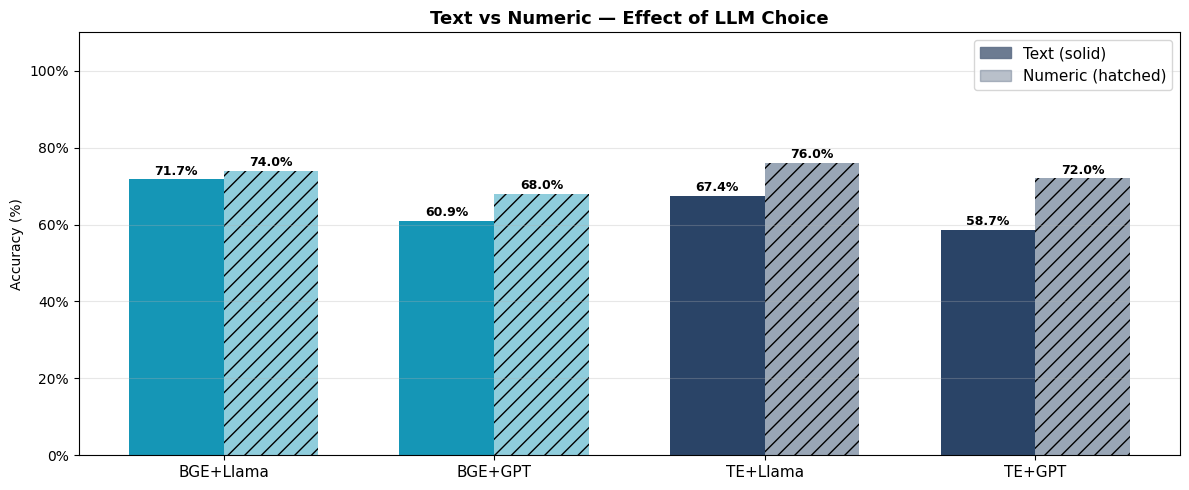

✓ llm_comparison_text_numeric.png


In [15]:
fig, ax = plt.subplots(figsize=(12, 5))

results = []
for label in FILES:
    if label not in dfs: continue
    df = dfs[label]
    results.append({
        'short':   SHORT[label],
        'numeric': df[df['attribute'].isin(NUMERIC_ATTRIBUTES)]['std'].mean()*100,
        'text':    df[df['attribute'].isin(TEXT_ATTRIBUTES)]['std'].mean()*100,
    })
res_df = pd.DataFrame(results)

x = np.arange(len(res_df)); w = 0.35
CMAP = [TEAL, TEAL, NAVY, NAVY]
b1 = ax.bar(x-w/2, res_df['text'],    w, color=CMAP[:len(res_df)], alpha=0.95, label='Text attrs (CE eval)')
b2 = ax.bar(x+w/2, res_df['numeric'], w, color=CMAP[:len(res_df)], alpha=0.45, hatch='//', label='Numeric attrs (exact match)')

for bar in list(b1)+list(b2):
    if bar.get_height() > 0:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(res_df['short'], fontsize=11)
ax.set_ylabel('Accuracy (%)'); ax.set_ylim(0, 110)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title('Text vs Numeric — Effect of LLM Choice', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

textp    = mpatches.Patch(color=GREY, alpha=0.95, label='Text (solid)')
numericp = mpatches.Patch(color=GREY, alpha=0.45, label='Numeric (hatched)')
ax.legend(handles=[textp, numericp], fontsize=11)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/llm_comparison_text_numeric.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ llm_comparison_text_numeric.png')

## 4. Full Summary Table

In [16]:
print('='*65)
print('FULL COMPARISON — Llama 3.1 8B vs GPT-4o-mini')
print('='*65)
print(f'\n{"Config":<15} {"Standard":>10} {"CE eval":>10} {"UNKNOWN":>10}')
print('-'*48)
for _, r in sum_df.iterrows():
    print(f'  {r["short"]:<13} {r["std"]:>9.1f}% {r["ce"]:>9.1f}% {r["unknown"]:>9.1f}%')

# Delta summary
print(f'\nΔ GPT-4o-mini vs Llama:')
for embedder, lk, gk in [
    ('BGE', 'BGE+RR\nLlama 3.1 8B', 'BGE+RR\nGPT-4o-mini'),
    ('TE',  'TE+RR\nLlama 3.1 8B',  'TE+RR\nGPT-4o-mini')
]:
    if lk not in dfs or gk not in dfs: continue
    l = sum_df[sum_df['label']==lk].iloc[0]
    g = sum_df[sum_df['label']==gk].iloc[0]
    print(f'  {embedder}: Std {g["std"]-l["std"]:+.1f}pp | CE {g["ce"]-l["ce"]:+.1f}pp | UNK {g["unknown"]-l["unknown"]:+.1f}pp')

# Key insight
print(f'\nKey insight:')
if 'BGE+RR\nGPT-4o-mini' in dfs and 'BGE+RR\nLlama 3.1 8B' in dfs:
    bge_l = sum_df[sum_df['label']=='BGE+RR\nLlama 3.1 8B'].iloc[0]
    bge_g = sum_df[sum_df['label']=='BGE+RR\nGPT-4o-mini'].iloc[0]
    delta = bge_g['std'] - bge_l['std']
    if delta > 3:
        print(f'  GPT-4o-mini improves BGE+RR by {delta:+.1f}pp → LLM capability IS a bottleneck')
    elif delta > 0:
        print(f'  GPT-4o-mini marginally improves BGE+RR by {delta:+.1f}pp → retrieval is the main bottleneck')
    else:
        print(f'  GPT-4o-mini does not improve BGE+RR ({delta:+.1f}pp) → retrieval precision is the bottleneck')

sum_df[['short','std','ce','unknown','n']].round(1)

FULL COMPARISON — Llama 3.1 8B vs GPT-4o-mini

Config            Standard    CE eval    UNKNOWN
------------------------------------------------
  BGE+Llama          72.9%      78.1%       3.1%
  BGE+GPT            64.6%      67.7%      27.1%
  TE+Llama           71.9%      83.3%       2.1%
  TE+GPT             65.6%      70.8%      22.9%

Δ GPT-4o-mini vs Llama:
  BGE: Std -8.3pp | CE -10.4pp | UNK +24.0pp
  TE: Std -6.2pp | CE -12.5pp | UNK +20.8pp

Key insight:
  GPT-4o-mini does not improve BGE+RR (-8.3pp) → retrieval precision is the bottleneck


,short,std,ce,unknown,n
0,BGE+Llama,72.9,78.1,3.1,96
1,BGE+GPT,64.6,67.7,27.1,96
2,TE+Llama,71.9,83.3,2.1,96
3,TE+GPT,65.6,70.8,22.9,96


## 5. Per-Attribute Detail Table

In [17]:
print(f'{"Attribute":<25}', end='')
for label in FILES:
    if label in dfs:
        print(f'{SHORT[label]:>12}', end='')
print()
print('-'*(25+12*len(dfs)))

for attr in attrs:
    t = 'NUM' if attr in NUMERIC_ATTRIBUTES else 'TXT'
    print(f'  {attr:<20} [{t}]', end='')
    for label in FILES:
        if label not in dfs: continue
        acc = dfs[label][dfs[label]['attribute']==attr]['std'].mean()*100
        print(f'{acc:>11.1f}%', end='')
    print()

Attribute                   BGE+Llama     BGE+GPT    TE+Llama      TE+GPT
-------------------------------------------------------------------------
  bus_type             [TXT]       92.3%       69.2%       84.6%       69.2%
  height_mm            [NUM]       69.2%       69.2%       76.9%       69.2%
  model                [TXT]       50.0%       70.0%       40.0%       50.0%
  model_number         [TXT]       69.6%       52.2%       69.6%       56.5%
  read_speed_mb_s      [NUM]       80.0%       66.7%       80.0%       66.7%
  width_mm             [NUM]       58.3%       58.3%       66.7%       75.0%
  write_speed_mb_s     [NUM]       90.0%       80.0%       80.0%       80.0%
